# Modélisation de la fonction de masse des amas
On implémente ici plusieurs versions de la fonction de masse des amas $\frac{dn}{dM}(z)$ ($Mpc^{-3} dex^{-1}$), c'est à dire la densité volumique d'amas de galaxies de masse comprises dans l'intervalle $[M - dM ; M + dM]$ pour un certain redshift z. 

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
import pickle
import os

In [2]:
from halo_and_cluster_MF import HMF_MRP,CMF_MRP

# Murray, Robotham and Power 
Voir Murray, Robotham, Power 2013 / Murray et al. 2021 / Driver et al. 2022

In [3]:
# On prend différents quelques lots de paramètres issus de Driver et al .2021 (on prend ceux issus d'un fit sur plusieurs relevés)
# Les paramètres sont de la forme : (log10_Mmedian_Msun,log10_phimedian,alpha,beta)

# Params GSR (GAMA5 + SDSS5 + REFLEX II) : ce sont les paramètres finalament retenus dans Driver et al. 2021
params_GSR = [14.13,-3.96,-1.68,0.63] # valeurs moyennes 
params_GSR_max = [14.13+0.43,-3.96+0.55,-1.68+0.21,0.63+0.25] # Borne max erreurs à 1 sigma
params_GSR_min = [14.13-0.40,-3.96-0.82,-1.68-0.24,0.63-0.11] # Borne min erreurs à 1 sigma

In [4]:
#On paramètres les CMF (Cluster Mass Function)

#GSR
CMF_GSR_func = CMF_MRP(params_GSR[0],params_GSR[1],params_GSR[2],params_GSR[3])
CMF_GSR_max_func = CMF_MRP(params_GSR_max[0],params_GSR_max[1],params_GSR_max[2],params_GSR_max[3])
CMF_GSR_min_func = CMF_MRP(params_GSR_min[0],params_GSR_min[1],params_GSR_min[2],params_GSR_min[3])

In [5]:
log10_M_Msun = np.linspace(12.7,15.5,1000) # Les fits desquels sont issus les paramètres sont valables pour des masses comprises entre 10^12.7 et 10^15.5 Msun
log10_M_Msun = log10_M_Msun.tolist()

print(log10_M_Msun)
type(log10_M_Msun)

[12.7, 12.702802802802802, 12.705605605605605, 12.708408408408408, 12.71121121121121, 12.714014014014014, 12.716816816816817, 12.71961961961962, 12.722422422422422, 12.725225225225225, 12.728028028028028, 12.730830830830831, 12.733633633633634, 12.736436436436435, 12.739239239239238, 12.74204204204204, 12.744844844844843, 12.747647647647646, 12.75045045045045, 12.753253253253252, 12.756056056056055, 12.758858858858858, 12.76166166166166, 12.764464464464464, 12.767267267267266, 12.77007007007007, 12.772872872872872, 12.775675675675675, 12.778478478478478, 12.78128128128128, 12.784084084084084, 12.786886886886887, 12.78968968968969, 12.792492492492492, 12.795295295295295, 12.798098098098098, 12.800900900900901, 12.803703703703704, 12.806506506506507, 12.809309309309308, 12.81211211211211, 12.814914914914914, 12.817717717717716, 12.82052052052052, 12.823323323323322, 12.826126126126125, 12.828928928928928, 12.83173173173173, 12.834534534534534, 12.837337337337337, 12.84014014014014, 12.84

list

In [6]:
CMF_GSR = CMF_GSR_func(log10_M_Msun)
CMF_GSR_max = CMF_GSR_max_func(log10_M_Msun)
CMF_GSR_min = CMF_GSR_min_func(log10_M_Msun)

In [8]:
CMF_GSR

array([1.54873125e-03, 1.54116050e-03, 1.53362355e-03, 1.52612027e-03,
       1.51865050e-03, 1.51121411e-03, 1.50381094e-03, 1.49644085e-03,
       1.48910371e-03, 1.48179936e-03, 1.47452766e-03, 1.46728847e-03,
       1.46008165e-03, 1.45290706e-03, 1.44576456e-03, 1.43865401e-03,
       1.43157528e-03, 1.42452821e-03, 1.41751268e-03, 1.41052855e-03,
       1.40357568e-03, 1.39665393e-03, 1.38976318e-03, 1.38290328e-03,
       1.37607411e-03, 1.36927552e-03, 1.36250739e-03, 1.35576959e-03,
       1.34906198e-03, 1.34238443e-03, 1.33573681e-03, 1.32911899e-03,
       1.32253085e-03, 1.31597224e-03, 1.30944306e-03, 1.30294315e-03,
       1.29647242e-03, 1.29003071e-03, 1.28361791e-03, 1.27723390e-03,
       1.27087854e-03, 1.26455171e-03, 1.25825330e-03, 1.25198317e-03,
       1.24574121e-03, 1.23952728e-03, 1.23334128e-03, 1.22718308e-03,
       1.22105255e-03, 1.21494959e-03, 1.20887406e-03, 1.20282585e-03,
       1.19680485e-03, 1.19081093e-03, 1.18484397e-03, 1.17890387e-03,
      

Text(0, 0.5, 'dn/(dlog10 (M/M$_{\\odot}$))')

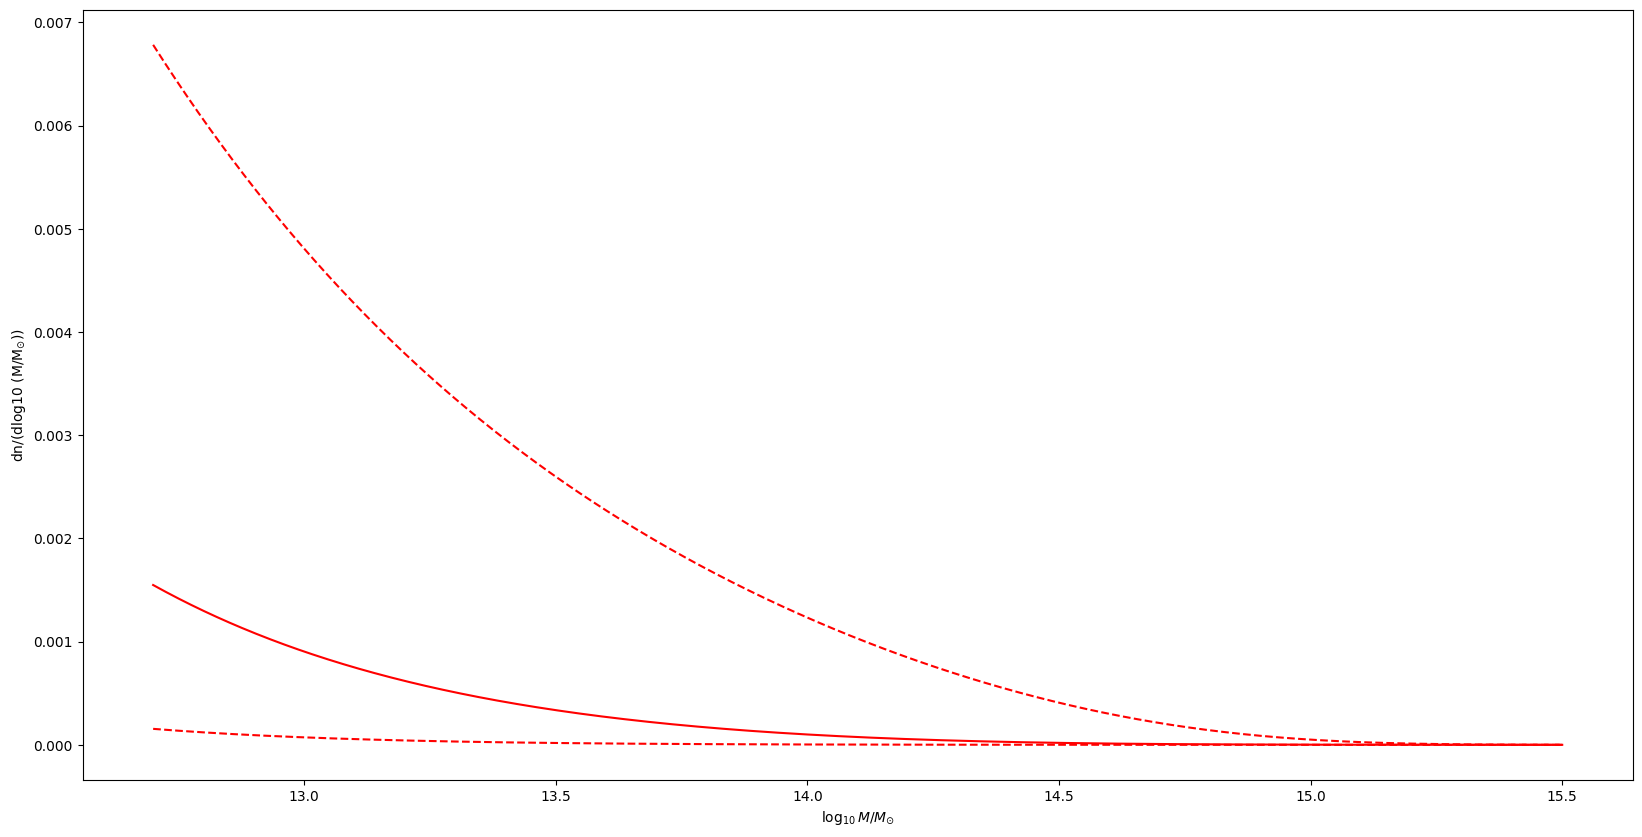

In [21]:
fig = plt.figure(figsize=(20, 10))
plt.plot(log10_M_Msun, CMF_GSR, label='CMF GSR', color='red')
plt.plot(log10_M_Msun, CMF_GSR_min, label='CMF GSR', color='red',linestyle='dashed')
plt.plot(log10_M_Msun, CMF_GSR_max, label='CMF GSR', color='red',linestyle='dashed')
plt.xlabel(r'$\log_{10} M / M_{\odot}$')
plt.ylabel(r'dn/(dlog10 (M/M$_{\odot}$))')